In [2]:
import pandas as pd
import numpy as np

In [3]:
import os

print(os.getcwd())
print(os.listdir())

e:\pvt green fleet\greenfleetsih\GreenFleet\ml
['benchmark_results.png', 'data', 'evaluate.py', 'fule_prediction.ipynb', 'models', 'train.py']


In [4]:
import os

print(os.listdir('data'))

['ship_fuel_efficiency.csv']


In [5]:
df = pd.read_csv('data/ship_fuel_efficiency.csv')

KeyError: 'ship_type'

In [6]:
df.head()

,ship_id,ship_type,route_id,month,distance,fuel_type,fuel_consumption,CO2_emissions,weather_conditions,engine_efficiency
0,NG001,Oil Service Boat,Warri-Bonny,January,132.26,HFO,3779.77,10625.76,Stormy,92.14
1,NG001,Oil Service Boat,Port Harcourt-Lagos,February,128.52,HFO,4461.44,12779.73,Moderate,92.98
2,NG001,Oil Service Boat,Port Harcourt-Lagos,March,67.30,HFO,1867.73,5353.01,Calm,87.61
3,NG001,Oil Service Boat,Port Harcourt-Lagos,April,71.68,Diesel,2393.51,6506.52,Stormy,87.42
4,NG001,Oil Service Boat,Lagos-Apapa,May,134.32,HFO,4267.19,11617.03,Calm,85.61


In [7]:
df.shape

(1440, 10)

KeyError: 'shipe_type'

In [8]:
df.count().notnull()

ship_id               True
ship_type             True
route_id              True
month                 True
distance              True
fuel_type             True
fuel_consumption      True
CO2_emissions         True
weather_conditions    True
engine_efficiency     True
dtype: bool

In [9]:
df.describe()

,distance,fuel_consumption,CO2_emissions,engine_efficiency
count,1440.000000,1440.000000,1440.000000,1440.000000
mean,151.753354,4844.246535,13365.454882,82.582924
std,108.472230,4892.352813,13567.650118,7.158289
min,20.080000,237.880000,615.680000,70.010000
25%,79.002500,1837.962500,4991.485000,76.255000
50%,123.465000,3060.880000,8423.255000,82.775000
75%,180.780000,4870.675000,13447.120000,88.862500
max,498.550000,24648.520000,71871.210000,94.980000


In [10]:
df.isnull().sum()

ship_id               0
ship_type             0
route_id              0
month                 0
distance              0
fuel_type             0
fuel_consumption      0
CO2_emissions         0
weather_conditions    0
engine_efficiency     0
dtype: int64

In [11]:
df.duplicated().sum()


np.int64(0)

In [12]:
df.dtypes

ship_id                   str
ship_type                 str
route_id                  str
month                     str
distance              float64
fuel_type                 str
fuel_consumption      float64
CO2_emissions         float64
weather_conditions        str
engine_efficiency     float64
dtype: object

In [13]:
df.columns


Index(['ship_id', 'ship_type', 'route_id', 'month', 'distance', 'fuel_type',
       'fuel_consumption', 'CO2_emissions', 'weather_conditions',
       'engine_efficiency'],
      dtype='str')

In [14]:
cols= ['ship_id', 'ship_type', 'route_id', 'month', 'distance', 'fuel_type',
       'fuel_consumption', 'CO2_emissions', 'weather_conditions',
       'engine_efficiency']
for c in cols:
    print(df[c].unique())

<StringArray>
['NG001', 'NG002', 'NG003', 'NG004', 'NG005', 'NG006', 'NG007', 'NG008',
 'NG009', 'NG010',
 ...
 'NG111', 'NG112', 'NG113', 'NG114', 'NG115', 'NG116', 'NG117', 'NG118',
 'NG119', 'NG120']
Length: 120, dtype: str
<StringArray>
['Oil Service Boat', 'Fishing Trawler', 'Surfer Boat', 'Tanker Ship']
Length: 4, dtype: str
<StringArray>
['Warri-Bonny', 'Port Harcourt-Lagos', 'Lagos-Apapa', 'Escravos-Lagos']
Length: 4, dtype: str
<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str
[132.26 128.52  67.3  ... 193.09 166.5  127.66]
<StringArray>
['HFO', 'Diesel']
Length: 2, dtype: str
[3779.77 4461.44 1867.73 ... 4661.63 4298.   3549.91]
[10625.76 12779.73  5353.01 ... 12267.13 12297.71 10641.9 ]
<StringArray>
['Stormy', 'Moderate', 'Calm']
Length: 3, dtype: str
[92.14 92.98 87.61 ... 79.67 92.87 90.82]


In [15]:
print(df[['distance', 'fuel_consumption', 'CO2_emissions', 'engine_efficiency']].describe())


          distance  fuel_consumption  CO2_emissions  engine_efficiency
count  1440.000000       1440.000000    1440.000000        1440.000000
mean    151.753354       4844.246535   13365.454882          82.582924
std     108.472230       4892.352813   13567.650118           7.158289
min      20.080000        237.880000     615.680000          70.010000
25%      79.002500       1837.962500    4991.485000          76.255000
50%     123.465000       3060.880000    8423.255000          82.775000
75%     180.780000       4870.675000   13447.120000          88.862500
max     498.550000      24648.520000   71871.210000          94.980000


In [16]:
print((df[['distance', 'fuel_consumption', 'CO2_emissions', 'engine_efficiency']] < 0).sum())

distance             0
fuel_consumption     0
CO2_emissions        0
engine_efficiency    0
dtype: int64


In [17]:
df = df[(df['distance'] > 0) & (df['fuel_consumption'] > 0) & (df['CO2_emissions'] > 0)]

In [18]:
df.dropna(subset=['fuel_consumption', 'CO2_emissions'], inplace=True)

In [19]:
cols_cat = ['ship_type', 'fuel_type', 'weather_conditions']
df[cols_cat] = df[cols_cat].fillna('Unknown')

In [20]:
df['engine_efficiency'].fillna(df['engine_efficiency'].median(), inplace=True)

C:\Users\Spandn\AppData\Local\Temp\ipykernel_23708\3478143380.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['engine_efficiency'].fillna(df['engine_efficiency'].median(), inplace=True)


0       92.14
1       92.98
2       87.61
3       87.42
4       85.61
        ...  
1435    75.88
1436    78.00
1437    79.67
1438    92.87
1439    90.82
Name: engine_efficiency, Length: 1440, dtype: float64

In [21]:
# Create sine and cosine features based on a 12-month cycle
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Drop the original raw month column
df.drop('month', axis=1, inplace=True)

TypeError: can't multiply sequence by non-int of type 'float'

In [ ]:
df['month'].unique()


<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

In [22]:
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

df['month'] = df['month'].map(month_map)

In [23]:
df['month']

0        1
1        2
2        3
3        4
4        5
        ..
1435     8
1436     9
1437    10
1438    11
1439    12
Name: month, Length: 1440, dtype: int64

In [24]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df.drop('month', axis=1, inplace=True)

In [25]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/ship_fuel_efficiency.csv')

In [26]:
df['month'].unique()

<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

In [27]:
import numpy as np

month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

df['month'] = df['month'].map(month_map)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df.drop('month', axis=1, inplace=True)

In [28]:
df.drop('ship_id', axis=1, inplace=True)

In [29]:
route_target_mean = df.groupby('route_id')['fuel_consumption'].mean()

In [30]:
df['route_avg_fuel'] = df['route_id'].map(route_target_mean)

In [31]:
df.drop('route_id', axis=1, inplace=True)

In [32]:
df = pd.get_dummies(df, columns=['ship_type', 'fuel_type', 'weather_conditions'], drop_first=True)

In [33]:
df.head()

,distance,fuel_consumption,CO2_emissions,engine_efficiency,month_sin,month_cos,route_avg_fuel,ship_type_Oil Service Boat,ship_type_Surfer Boat,ship_type_Tanker Ship,fuel_type_HFO,weather_conditions_Moderate,weather_conditions_Stormy
0,132.26,3779.77,10625.76,92.14,0.500000,8.660254e-01,4353.314048,True,False,False,True,False,True
1,128.52,4461.44,12779.73,92.98,0.866025,5.000000e-01,4805.137301,True,False,False,True,True,False
2,67.30,1867.73,5353.01,87.61,1.000000,6.123234e-17,4805.137301,True,False,False,True,False,False
3,71.68,2393.51,6506.52,87.42,0.866025,-5.000000e-01,4805.137301,True,False,False,False,False,True
4,134.32,4267.19,11617.03,85.61,0.500000,-8.660254e-01,5171.549716,True,False,False,True,False,False


In [34]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


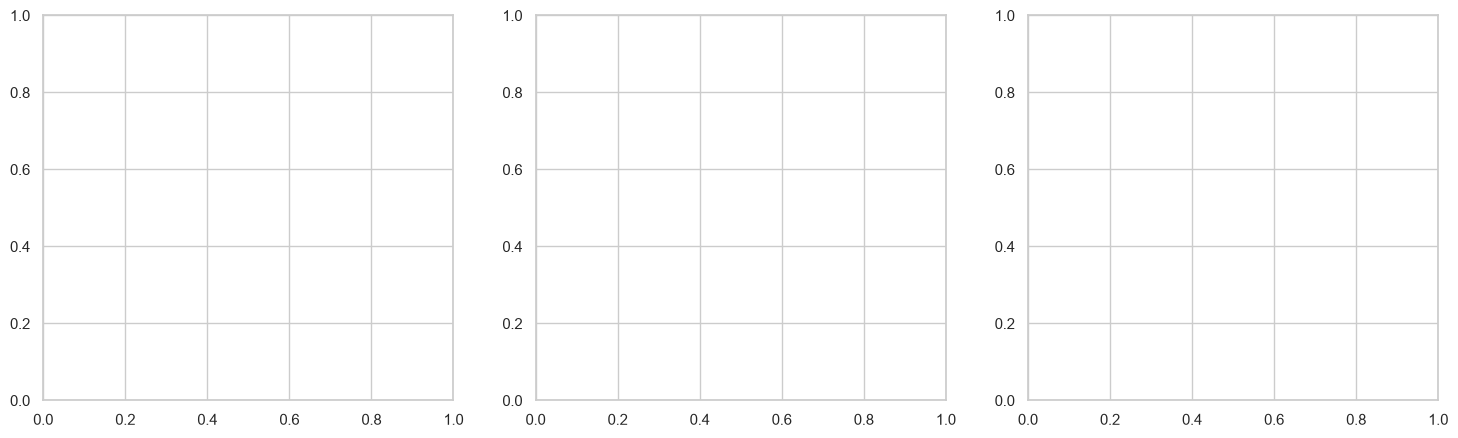

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

In [55]:
sns.scatterplot(data=df, x='distance', y='fuel_consumption', alpha=0.5, ax=axes[0])
axes[0].set_title('Fuel vs Distance (Physics Check)')

Text(0.5, 1.0, 'Fuel vs Distance (Physics Check)')

In [63]:
%pip install scikit-learn

  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------------- ---------------------- 3.7/8.3 MB 24.3 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 12.4 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 9.1 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 7.4 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 6.2 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 5.5 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 5.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
   - -------------------------------------- 1.0/36.7 MB 5.6 MB/s eta 0:00:07
   -- ------------------------------------- 2.4/36.7 MB 5.8 MB/s eta 0:00:06
   ---- --------------------------


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
from sklearn.model_selection import train_test_split

In [68]:
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
df['month_num'] = df['month_sin'].map(month_map)

In [70]:
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
df.drop(['month_sin', 'month_num'], axis=1, inplace=True)

In [73]:
df.columns

Index(['distance', 'fuel_consumption', 'CO2_emissions', 'engine_efficiency',
       'month_cos', 'route_avg_fuel', 'ship_type_Oil Service Boat',
       'ship_type_Surfer Boat', 'ship_type_Tanker Ship', 'fuel_type_HFO',
       'weather_conditions_Moderate', 'weather_conditions_Stormy'],
      dtype='str')

In [74]:
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}

In [75]:
if 'month' in df.columns:
    df['month_num'] = df['month'].map(month_map)

In [78]:
df = pd.read_csv('data/ship_fuel_efficiency.csv')

In [79]:
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

df['month_num'] = df['month'].map(month_map)

df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)

In [80]:
df.head()

,ship_id,ship_type,route_id,month,distance,fuel_type,fuel_consumption,CO2_emissions,weather_conditions,engine_efficiency,month_num,month_sin,month_cos
0,NG001,Oil Service Boat,Warri-Bonny,January,132.26,HFO,3779.77,10625.76,Stormy,92.14,1,0.500000,8.660254e-01
1,NG001,Oil Service Boat,Port Harcourt-Lagos,February,128.52,HFO,4461.44,12779.73,Moderate,92.98,2,0.866025,5.000000e-01
2,NG001,Oil Service Boat,Port Harcourt-Lagos,March,67.30,HFO,1867.73,5353.01,Calm,87.61,3,1.000000,6.123234e-17
3,NG001,Oil Service Boat,Port Harcourt-Lagos,April,71.68,Diesel,2393.51,6506.52,Stormy,87.42,4,0.866025,-5.000000e-01
4,NG001,Oil Service Boat,Lagos-Apapa,May,134.32,HFO,4267.19,11617.03,Calm,85.61,5,0.500000,-8.660254e-01


In [81]:
df = df[(df['distance'] > 0) & (df['fuel_consumption'] > 0) & (df['CO2_emissions'] > 0)]

In [82]:
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
df['month_num'] = df['month'].map(month_map)

In [83]:
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)

In [84]:
df.drop(['month', 'month_num'], axis=1, inplace=True)

In [85]:
route_target_mean = df.groupby('route_id')['fuel_consumption'].mean()
df['route_avg_fuel'] = df['route_id'].map(route_target_mean)

In [86]:
df.drop(['ship_id', 'route_id'], axis=1, inplace=True)

In [87]:
df = pd.get_dummies(df, columns=['ship_type', 'fuel_type', 'weather_conditions'], drop_first=True)

In [88]:
X = df.drop(columns=['fuel_consumption', 'CO2_emissions'])
y = df['fuel_consumption']

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [91]:
%pip install xgboost

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
xgb_baseline = XGBRegressor(random_state=42)

In [94]:
xgb_baseline.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [95]:
y_pred_baseline = xgb_baseline.predict(X_test)

In [96]:
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

In [97]:
print("--- XGBoost Baseline Performance ---")
print(f"MAE:  {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"R²:   {baseline_r2:.4f}")

--- XGBoost Baseline Performance ---
MAE:  698.70
RMSE: 1264.39
R²:   0.9406


In [98]:
import joblib
import os
import matplotlib.pyplot as plt
import numpy as np

In [99]:
feature_importances = xgb_baseline.feature_importances_
features = X_train.columns
indices = np.argsort(feature_importances)[::-1]

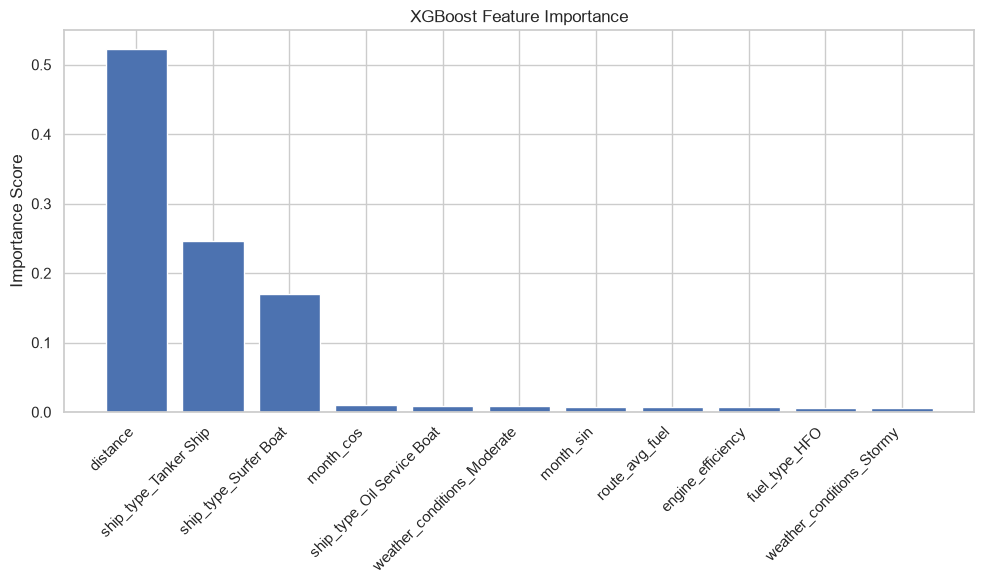

In [100]:
plt.figure(figsize=(10, 6))
plt.title("XGBoost Feature Importance")
plt.bar(range(X_train.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), features[indices], rotation=45, ha='right')
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [101]:
os.makedirs("models", exist_ok=True)

In [102]:
model_path = "models/xgboost_fuel_model.pkl"
joblib.dump(xgb_baseline, model_path)

['models/xgboost_fuel_model.pkl']

In [39]:
df.columns

Index(['distance', 'fuel_consumption', 'CO2_emissions', 'engine_efficiency',
       'month_sin', 'month_cos', 'route_avg_fuel',
       'ship_type_Oil Service Boat', 'ship_type_Surfer Boat',
       'ship_type_Tanker Ship', 'fuel_type_HFO', 'weather_conditions_Moderate',
       'weather_conditions_Stormy'],
      dtype='str')